# 1. Pattern Generation

This notebook will show you how to simulate XRD patterns.

In [1]:
# @title Environment Setup
!pip install pymatgen numpy matplotlib -q
print("Packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.3 MB/s eta 0:00:00
Packages installed


In [2]:
# @title Load Tutorial Data
import os

REPO = "MRS_CH08_Tutorial"
REPO_URL = "https://github.com/Szymanski-Group/MRS_CH08_Tutorial.git"

if os.path.basename(os.getcwd()) == REPO:
    print("✅ Data already present")
elif os.path.exists(REPO):
    os.chdir(REPO)
    print("✅ Data already present")
else:
    !git clone {REPO_URL} -q
    os.chdir(REPO)
    print("✅ Data loaded successfully")


✅ Data loaded successfully


## 1a) Generating Stick Patterns

This notebook introduces idealized XRD stick patterns using NaCl as a simple reference system.

In [4]:
from IPython.display import Image, display

def create_stick_pattern(struc_path="data/cif/NaCl.cif",
                         min_angle=10, max_angle=80,
                         wavelen=1.5406 # Cu Ka
                         ):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    # Initialize XRD calculator on NaCl
    pattern = XRDCalculator(wavelength=wavelen).get_pattern(
        Structure.from_file(struc_path),
        two_theta_range=(min_angle, max_angle),
    )

    # Initialize plot
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot discrete peaks as vertical lines
    ax.vlines(pattern.x, 0, pattern.y, color="black", linewidth=6.5)

    # Formatting
    ax.set_xlim(min_angle, max_angle)
    ax.set_ylim(0, max(pattern.y) * 1.05)
    ax.set_xlabel("2θ", fontsize=18, labelpad=12)
    ax.set_ylabel("Intensity", fontsize=18, labelpad=12)
    ax.tick_params(axis="both", labelsize=15)

    # Save plot
    plt.tight_layout()
    plt.savefig("stick_pattern.png", dpi=200)
    print("\nSaved plot: stick_pattern.png")




Saved plot: stick_pattern.png


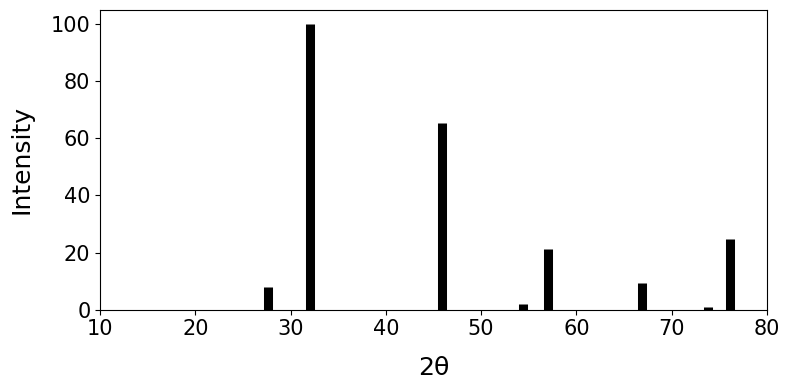

In [6]:
# @title Call the function
create_stick_pattern()


The vertical lines mark Bragg peak positions (2θ) and relative intensities for an ideal crystal.

In [9]:
# Try on your own:
  # Vary the wavelength (1.5406 Å is the CuKa value; you can specify others)
  # Load other structures (from data/cif) and plot their XRD stick patterns
  #Check how peaks look at higher values of two-theta

# create_stick_pattern(struc_path=, wavelen=, min_angle=, max_angle=)

## Summary
- Stick patterns show discrete reflection positions and intensities.
- Peak positions come from lattice geometry; heights come from structure factors.
- This is the baseline representation before instrumental/sample artifacts are added.

## 1b) Continuous Patterns

This section broadens stick peaks into a pseudo-Voigt profile to mimic realistic measured line shapes.


In [ ]:
def create_continuous_pattern(
    struc_path="data/cif/NaCl.cif",
    min_angle=10,
    max_angle=80,
    wavelen="CuKa",
    num_points=4000,
    fwhm=0.3,
    gauss_frac=0.2,
    fill_color="blue",
    line_color="darkblue",
    output_file="NaCl_continuous_pattern.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    def gaussian(x, center, fwhm):
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        return np.exp(-0.5 * ((x - center) / sigma) ** 2)

    def lorentzian(x, center, fwhm):
        gamma = fwhm / 2.0
        return (gamma**2) / ((x - center) ** 2 + gamma**2)

    def pseudo_voigt(x, center, fwhm, eta):
        return (1.0 - eta) * gaussian(x, center, fwhm) + eta * lorentzian(x, center, fwhm)

    pattern = XRDCalculator(wavelength=wavelen).get_pattern(
        Structure.from_file(struc_path),
        two_theta_range=(min_angle, max_angle),
    )

    peak_pos = np.array(pattern.x)
    peak_intensity = np.array(pattern.y)

    two_theta_grid = np.linspace(min_angle, max_angle, num_points)
    continuous_intensity = np.zeros_like(two_theta_grid)

    for two_theta, intensity in zip(peak_pos, peak_intensity):
        continuous_intensity += intensity * pseudo_voigt(
            two_theta_grid,
            two_theta,
            fwhm,
            gauss_frac,
        )

    continuous_intensity *= peak_intensity.max() / np.clip(
        continuous_intensity.max(),
        1e-12,
        None,
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.fill_between(two_theta_grid, 0, continuous_intensity, color=fill_color, alpha=0.25)
    ax.plot(two_theta_grid, continuous_intensity, color=line_color, linewidth=2.2)

    ax.set_xlim(min_angle, max_angle)
    ax.set_ylim(0, continuous_intensity.max() * 1.05)
    ax.set_xlabel("2θ", fontsize=18, labelpad=12)
    ax.set_ylabel("Intensity", fontsize=18, labelpad=12)
    ax.tick_params(axis="both", labelsize=15)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Saved plot: {output_file}")


In [ ]:
# @title Call the function
create_continuous_pattern()


The spectrum becomes continuous, and peak overlap starts to matter for phase identification.


In [ ]:
# Try on your own:
#   Increase fwhm to mimic lower instrument resolution
#   Change gauss_frac (0 = Gaussian, 1 = Lorentzian)
#   Load another structure from data/cif

# create_continuous_pattern(struc_path=, fwhm=, gauss_frac=)


## Summary
- Broadening turns ideal sticks into realistic peak envelopes.
- FWHM and Gaussian/Lorentzian mixing control profile shape.
- Continuous patterns are the starting point for fitting and inference workflows.


## 1c) Peak Splitting

This section adds Cu Kα1/Kα2 doublet splitting and highlights the effect at higher angles.


In [ ]:
def create_peak_splitting_pattern(
    struc_path="data/cif/NaCl.cif",
    min_angle=10,
    max_angle=80,
    num_points=4000,
    fwhm=0.1,
    gauss_frac=0.2,
    ka1_wavelength=1.5405929,
    ka2_wavelength=1.5444260,
    ka1_ka2_ratio=2.0,
    zoom_range=(75.0, 77.5),
    zoom_ylim=(0.0, 28.0),
    output_file="NaCl_peak_splitting_pattern.png",
    zoom_output_file="NaCl_zoomed.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    def gaussian(x, center, fwhm):
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        return np.exp(-0.5 * ((x - center) / sigma) ** 2)

    def lorentzian(x, center, fwhm):
        gamma = fwhm / 2.0
        return (gamma**2) / ((x - center) ** 2 + gamma**2)

    def pseudo_voigt(x, center, fwhm, eta):
        return (1.0 - eta) * gaussian(x, center, fwhm) + eta * lorentzian(x, center, fwhm)

    structure = Structure.from_file(struc_path)

    pattern_ka1 = XRDCalculator(wavelength=ka1_wavelength).get_pattern(
        structure,
        two_theta_range=(min_angle, max_angle),
    )
    pattern_ka2 = XRDCalculator(wavelength=ka2_wavelength).get_pattern(
        structure,
        two_theta_range=(min_angle, max_angle),
    )

    peak_pos_ka1 = np.array(pattern_ka1.x)
    peak_intensity_ka1 = np.array(pattern_ka1.y)
    peak_pos_ka2 = np.array(pattern_ka2.x)
    peak_intensity_ka2 = np.array(pattern_ka2.y)

    weight_ka1 = ka1_ka2_ratio / (1.0 + ka1_ka2_ratio)
    weight_ka2 = 1.0 / (1.0 + ka1_ka2_ratio)

    two_theta_grid = np.linspace(min_angle, max_angle, num_points)
    continuous_intensity = np.zeros_like(two_theta_grid)

    for two_theta, intensity in zip(peak_pos_ka1, peak_intensity_ka1):
        continuous_intensity += weight_ka1 * intensity * pseudo_voigt(
            two_theta_grid,
            two_theta,
            fwhm,
            gauss_frac,
        )

    for two_theta, intensity in zip(peak_pos_ka2, peak_intensity_ka2):
        continuous_intensity += weight_ka2 * intensity * pseudo_voigt(
            two_theta_grid,
            two_theta,
            fwhm,
            gauss_frac,
        )

    continuous_intensity *= 100.0 / np.clip(continuous_intensity.max(), 1e-12, None)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.fill_between(two_theta_grid, 0, continuous_intensity, color="blue", alpha=0.25)
    ax.plot(two_theta_grid, continuous_intensity, color="darkblue", linewidth=1.5)

    ax.set_xlim(min_angle, max_angle)
    ax.set_ylim(0, continuous_intensity.max() * 1.05)
    ax.set_xlabel("2θ", fontsize=18, labelpad=12)
    ax.set_ylabel("Intensity", fontsize=18, labelpad=12)
    ax.tick_params(axis="both", labelsize=15)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Saved plot: {output_file}")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.fill_between(two_theta_grid, 0, continuous_intensity, color="blue", alpha=0.25)
    ax.plot(two_theta_grid, continuous_intensity, color="darkblue", linewidth=1.5)

    ax.set_xlim(*zoom_range)
    ax.set_ylim(*zoom_ylim)

    plt.tight_layout()
    plt.savefig(zoom_output_file, dpi=200)
    print(f"Saved zoomed plot: {zoom_output_file}")


In [ ]:
# @title Call the function
create_peak_splitting_pattern()


The zoomed view makes subtle doublet separation visible at larger 2θ values.


In [ ]:
# Try on your own:
#   Expand max_angle to include more high-2theta peaks
#   Change fwhm to see when splitting becomes easier/harder to resolve
#   Adjust ka1_ka2_ratio to test source-intensity effects

# create_peak_splitting_pattern(max_angle=, fwhm=, ka1_ka2_ratio=)


## Summary
- Kα splitting creates near-duplicate peak components.
- High-angle reflections make splitting easiest to see.
- Ignoring splitting can bias peak-position or line-shape analysis.


## 1d) Peak Broadening

This section uses a Scherrer-style model to show how crystallite size impacts line width.


In [ ]:
def create_peak_broadening_comparison(
    struc_path="data/cif/TiO2.cif",
    min_angle=10,
    max_angle=80,
    num_points=4000,
    wavelen=1.5406,
    k_factor=0.9,
    profiles=(("Large particles", 30.0), ("Moderate size", 10.0), ("Very small", 5.0)),
    cmap_colors=("#1f4ed8", "#7e22ce", "#dc2626"),
    output_file="TiO2_peak_broadening.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    def scherrer_fwhm_deg(two_theta_deg, crystallite_size_nm):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        wavelength_nm = wavelen / 10.0
        beta_rad = k_factor * wavelength_nm / (crystallite_size_nm * np.cos(theta_rad))
        return np.rad2deg(beta_rad)

    def gaussian_unit_area(two_theta_grid, centers, fwhm_deg):
        sigma = fwhm_deg / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        dx = two_theta_grid[:, None] - centers[None, :]
        return np.exp(-0.5 * (dx / sigma[None, :]) ** 2) / (
            sigma[None, :] * np.sqrt(2.0 * np.pi)
        )

    def broaden_pattern(two_theta_grid, peak_pos, peak_intensity, size_nm):
        fwhm = scherrer_fwhm_deg(peak_pos, size_nm)
        profile = gaussian_unit_area(two_theta_grid, peak_pos, fwhm)
        intensity = profile @ peak_intensity
        return 100.0 * intensity / np.clip(intensity.max(), 1e-12, None)

    pattern = XRDCalculator(wavelength=wavelen).get_pattern(
        Structure.from_file(struc_path),
        two_theta_range=(min_angle, max_angle),
    )

    peak_pos = np.array(pattern.x)
    peak_intensity = np.array(pattern.y)
    peak_intensity = 100.0 * peak_intensity / np.clip(peak_intensity.max(), 1e-12, None)

    two_theta_grid = np.linspace(min_angle, max_angle, num_points)

    profile_cmap = LinearSegmentedColormap.from_list("size_profile_map", list(cmap_colors))
    colors = [profile_cmap(v) for v in np.linspace(0.0, 1.0, len(profiles))]

    fig, axes = plt.subplots(nrows=len(profiles), ncols=1, figsize=(8, 7), sharex=True)
    if len(profiles) == 1:
        axes = [axes]

    for ax, color, (label, size_nm) in zip(axes, colors, profiles):
        continuous_intensity = broaden_pattern(two_theta_grid, peak_pos, peak_intensity, size_nm)
        ax.fill_between(two_theta_grid, 0, continuous_intensity, color=color, alpha=0.25)
        ax.plot(two_theta_grid, continuous_intensity, color=color, linewidth=2.2)
        ax.set_title(f"{label} ({size_nm} nm)", fontsize=14, pad=4)
        ax.set_xlim(min_angle, max_angle)
        ax.set_ylim(0, 105)
        ax.set_ylabel("Intensity", fontsize=16, labelpad=10)
        ax.tick_params(axis="both", labelsize=13)

    axes[-1].set_xlabel("2θ", fontsize=16, labelpad=10)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Saved plot: {output_file}")
    print("Smaller crystallite size gives broader peaks (larger Scherrer FWHM).")


In [ ]:
# @title Call the function
create_peak_broadening_comparison()


Smaller crystallite size yields visibly broader peaks and reduced apparent resolution.


In [ ]:
# Try on your own:
#   Change particle sizes in profiles, e.g. (("Very large", 50.0), ("Nano", 4.0))
#   Change wavelen to simulate a different radiation source
#   Compare narrow and wide angle windows

# create_peak_broadening_comparison(profiles=, wavelen=, min_angle=, max_angle=)


## Summary
- Finite domain size broadens diffraction peaks.
- Broadening can obscure nearby reflections.
- Crystallite-size effects are a key source of non-ideal line shape.


## 1e) Baseline Effects

This section adds background curvature and noise on top of broadened peaks.


In [ ]:
def create_pattern_with_baseline(
    struc_path="data/cif/LiMnO2.cif",
    min_angle=10,
    max_angle=80,
    num_points=4000,
    eta=0.5,
    crystallite_size_nm=20.0,
    microstrain=0.001,
    u=0.04,
    v=-0.01,
    w=0.006,
    ka1_wavelength=1.5405929,
    ka2_wavelength=1.5444260,
    ka1_ka2_ratio=2.0,
    cheb_coeffs=(1.0, -0.3, 0.15, -0.05, 0.02),
    background_scale=0.24,
    noise_level=0.005,
    baseline_offset=0.01,
    random_seed=42,
    output_file="LiMnO2_xrd_with_background.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    rng = np.random.default_rng(random_seed)
    cheb_coeffs = np.array(cheb_coeffs, dtype=float)

    def instrumental_fwhm(two_theta_deg):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        tan_theta = np.tan(theta_rad)
        fwhm_sq = u * tan_theta**2 + v * tan_theta + w
        return np.sqrt(np.clip(fwhm_sq, 1e-4, None))

    def size_fwhm(two_theta_deg):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        wavelength_nm = ka1_wavelength / 10.0
        beta_rad = 0.9 * wavelength_nm / (crystallite_size_nm * np.cos(theta_rad))
        return np.rad2deg(beta_rad)

    def strain_fwhm(two_theta_deg):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        beta_rad = 4.0 * microstrain * np.tan(theta_rad)
        return np.rad2deg(beta_rad)

    def pseudo_voigt_profile(two_theta_grid, centers, fwhm, eta):
        dx = two_theta_grid[:, None] - centers[None, :]
        sigma = np.clip(fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0))), 1e-6, None)
        gamma = np.clip(fwhm / 2.0, 1e-6, None)
        gauss = np.exp(-0.5 * (dx / sigma[None, :]) ** 2)
        lorentz = (gamma[None, :] ** 2) / (dx**2 + gamma[None, :] ** 2)
        return (1.0 - eta) * gauss + eta * lorentz

    structure = Structure.from_file(struc_path)

    pattern_ka1 = XRDCalculator(wavelength=ka1_wavelength).get_pattern(
        structure,
        two_theta_range=(min_angle, max_angle),
    )
    pattern_ka2 = XRDCalculator(wavelength=ka2_wavelength).get_pattern(
        structure,
        two_theta_range=(min_angle, max_angle),
    )

    peak_pos_ka1 = np.array(pattern_ka1.x)
    peak_intensity_ka1 = np.array(pattern_ka1.y)
    peak_pos_ka2 = np.array(pattern_ka2.x)
    peak_intensity_ka2 = np.array(pattern_ka2.y)

    two_theta_grid = np.linspace(min_angle, max_angle, num_points)

    fwhm_ka1 = np.sqrt(
        instrumental_fwhm(peak_pos_ka1) ** 2
        + size_fwhm(peak_pos_ka1) ** 2
        + strain_fwhm(peak_pos_ka1) ** 2
    )
    fwhm_ka2 = np.sqrt(
        instrumental_fwhm(peak_pos_ka2) ** 2
        + size_fwhm(peak_pos_ka2) ** 2
        + strain_fwhm(peak_pos_ka2) ** 2
    )

    weight_ka1 = ka1_ka2_ratio / (1.0 + ka1_ka2_ratio)
    weight_ka2 = 1.0 / (1.0 + ka1_ka2_ratio)

    profile_ka1 = pseudo_voigt_profile(two_theta_grid, peak_pos_ka1, fwhm_ka1, eta) @ peak_intensity_ka1
    profile_ka2 = pseudo_voigt_profile(two_theta_grid, peak_pos_ka2, fwhm_ka2, eta) @ peak_intensity_ka2
    peaks = weight_ka1 * profile_ka1 + weight_ka2 * profile_ka2
    peaks *= max(peak_intensity_ka1.max(), peak_intensity_ka2.max()) / np.clip(peaks.max(), 1e-12, None)

    x_cheb = 2.0 * (two_theta_grid - min_angle) / (max_angle - min_angle) - 1.0
    background_shape = np.polynomial.chebyshev.chebval(x_cheb, cheb_coeffs)
    background_shape -= background_shape.min()
    background_shape /= np.clip(background_shape.max(), 1e-12, None)
    background = background_scale * peaks.max() * background_shape

    noise = rng.normal(loc=0.0, scale=noise_level * peaks.max(), size=num_points)

    intensity = peaks + background + noise
    intensity -= intensity.min()
    intensity += baseline_offset * peaks.max()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.fill_between(two_theta_grid, 0, intensity, color="black", alpha=0.15)
    ax.plot(two_theta_grid, intensity, color="black", linewidth=2.2)

    ax.set_xlim(min_angle, max_angle)
    ax.set_ylim(0, intensity.max() * 1.05)
    ax.set_xlabel("2θ", fontsize=18, labelpad=12)
    ax.set_ylabel("Intensity", fontsize=18, labelpad=12)
    ax.tick_params(axis="both", labelsize=15)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Saved plot: {output_file}")


In [ ]:
# @title Call the function
create_pattern_with_baseline()


Baseline shape and counting noise can dominate weak regions of the pattern.


In [ ]:
# Try on your own:
#   Change cheb_coeffs to make the baseline flatter or more curved
#   Increase/decrease background_scale to control baseline height
#   Increase/decrease noise_level to simulate cleaner/noisier data

# create_pattern_with_baseline(cheb_coeffs=, background_scale=, noise_level=)


## Summary
- Background modeling is essential before quantitative comparison.
- Noise level influences peak detection robustness.
- Even simple baseline terms can change interpretation of weak peaks.


## 1f) Lattice Strain

This section compares unstrained and strained TiO2 to visualize lattice-parameter-driven peak shifts.


In [ ]:
def create_lattice_strain_comparison(
    struc_path="data/cif/TiO2.cif",
    min_angle=10,
    max_angle=80,
    num_points=4000,
    wavelen=1.5406,
    k_factor=0.9,
    crystallite_size_nm=17.5,
    in_plane_strain=-0.015,
    out_of_plane_strain=-0.010,
    labels=("TiO2", "TiO2 strained"),
    colors=("#1f4ed8", "#dc2626"),
    output_file="TiO2_strained-xrd.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    def scherrer_fwhm_deg(two_theta_deg, crystallite_size_nm):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        wavelength_nm = wavelen / 10.0
        beta_rad = k_factor * wavelength_nm / (crystallite_size_nm * np.cos(theta_rad))
        return np.rad2deg(beta_rad)

    def gaussian_unit_area(two_theta_grid, centers, fwhm_deg):
        sigma = fwhm_deg / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        dx = two_theta_grid[:, None] - centers[None, :]
        return np.exp(-0.5 * (dx / sigma[None, :]) ** 2) / (
            sigma[None, :] * np.sqrt(2.0 * np.pi)
        )

    def broaden_pattern(two_theta_grid, peak_pos, peak_intensity, size_nm):
        fwhm = scherrer_fwhm_deg(peak_pos, size_nm)
        profile = gaussian_unit_area(two_theta_grid, peak_pos, fwhm)
        intensity = profile @ peak_intensity
        return 100.0 * intensity / np.clip(intensity.max(), 1e-12, None)

    original_structure = Structure.from_file(struc_path)
    strained_structure = original_structure.copy()
    strained_structure.apply_strain([in_plane_strain, in_plane_strain, out_of_plane_strain])

    two_theta_grid = np.linspace(min_angle, max_angle, num_points)
    calc = XRDCalculator(wavelength=wavelen)

    fig, ax = plt.subplots(figsize=(8, 2.5))

    for structure, label, color in zip(
        (original_structure, strained_structure),
        labels,
        colors,
    ):
        pattern = calc.get_pattern(structure, two_theta_range=(min_angle, max_angle))
        peak_pos = np.array(pattern.x)
        peak_intensity = np.array(pattern.y)
        peak_intensity = 100.0 * peak_intensity / np.clip(peak_intensity.max(), 1e-12, None)

        continuous_intensity = broaden_pattern(
            two_theta_grid,
            peak_pos,
            peak_intensity,
            crystallite_size_nm,
        )
        ax.fill_between(two_theta_grid, 0, continuous_intensity, color=color, alpha=0.25)
        ax.plot(two_theta_grid, continuous_intensity, color=color, linewidth=2.2, label=label)

    ax.set_xlim(min_angle, max_angle)
    ax.set_ylim(0, 105)
    ax.tick_params(axis="both", labelsize=15)
    ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Saved plot: {output_file}")


In [ ]:
# @title Call the function
create_lattice_strain_comparison()


Strain changes d-spacings, shifting peak positions while preserving overall phase identity.


In [ ]:
# Try on your own:
#   Change in_plane_strain and out_of_plane_strain, then compare peak shifts
#   Increase crystallite_size_nm to separate strain effects from broadening
#   Adjust min_angle/max_angle to focus on sensitive regions

# create_lattice_strain_comparison(in_plane_strain=, out_of_plane_strain=, crystallite_size_nm=)


## Summary
- Lattice strain primarily shifts peak positions.
- Shift direction and magnitude depend on strain tensor components.
- Position-sensitive matching can capture strain effects that intensity-only matching misses.


## 1g) Texture

This section models preferred orientation with a March-Dollase correction to modify reflection intensities.


In [ ]:
def create_texture_comparison(
    struc_path="data/cif/TiO2.cif",
    min_angle=10,
    max_angle=80,
    num_points=4000,
    wavelen="CuKa",
    fwhm=0.4,
    gauss_frac=0.2,
    preferred_orientation=(0, 0, 1),
    march_dollase_r=0.65,
    output_file="TiO2_texture_comparison.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    def gaussian(x, center, fwhm):
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        return np.exp(-0.5 * ((x - center) / sigma) ** 2)

    def lorentzian(x, center, fwhm):
        gamma = fwhm / 2.0
        return (gamma**2) / ((x - center) ** 2 + gamma**2)

    def pseudo_voigt(x, center, fwhm, eta):
        return (1.0 - eta) * gaussian(x, center, fwhm) + eta * lorentzian(x, center, fwhm)

    def march_dollase_factor(hkls, preferred_orientation, r):
        hkls = np.asarray(hkls, dtype=float)
        preferred = np.asarray(preferred_orientation, dtype=float)

        preferred_mag = np.linalg.norm(preferred)
        if preferred_mag < 1e-12:
            raise ValueError("Preferred orientation vector must be non-zero.")

        hkl_mag = np.linalg.norm(hkls, axis=1)
        hkl_mag = np.clip(hkl_mag, 1e-12, None)

        cos_alpha = (hkls @ preferred) / (hkl_mag * preferred_mag)
        cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
        sin_alpha_sq = 1.0 - cos_alpha**2

        r = max(float(r), 1e-6)
        numerator = r * r * cos_alpha**2 + sin_alpha_sq / r
        numerator = np.clip(numerator, 1e-12, None)
        return numerator ** (-1.5)

    def continuous_profile(two_theta_grid, peak_pos, peak_intensity, fwhm, eta):
        intensity = np.zeros_like(two_theta_grid)
        for two_theta, peak_height in zip(peak_pos, peak_intensity):
            intensity += peak_height * pseudo_voigt(two_theta_grid, two_theta, fwhm, eta)
        return 100.0 * intensity / np.clip(intensity.max(), 1e-12, None)

    pattern = XRDCalculator(wavelength=wavelen).get_pattern(
        Structure.from_file(struc_path),
        two_theta_range=(min_angle, max_angle),
    )

    peak_pos = np.array(pattern.x)
    peak_intensity = np.array(pattern.y)
    peak_hkls = np.array([h[0]["hkl"] for h in pattern.hkls], dtype=float)

    intensity_no_texture = peak_intensity.copy()
    texture_scale = march_dollase_factor(peak_hkls, preferred_orientation, march_dollase_r)
    intensity_with_texture = peak_intensity * texture_scale

    two_theta_grid = np.linspace(min_angle, max_angle, num_points)
    continuous_no_texture = continuous_profile(
        two_theta_grid,
        peak_pos,
        intensity_no_texture,
        fwhm,
        gauss_frac,
    )
    continuous_with_texture = continuous_profile(
        two_theta_grid,
        peak_pos,
        intensity_with_texture,
        fwhm,
        gauss_frac,
    )

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), sharex=True)

    axes[0].fill_between(two_theta_grid, 0, continuous_no_texture, color="#1f4ed8", alpha=0.25)
    axes[0].plot(two_theta_grid, continuous_no_texture, color="#1f4ed8", linewidth=2.2)
    axes[0].set_title("Without texture", fontsize=16, pad=4)

    axes[1].fill_between(two_theta_grid, 0, continuous_with_texture, color="#dc2626", alpha=0.25)
    axes[1].plot(two_theta_grid, continuous_with_texture, color="#dc2626", linewidth=2.2)
    axes[1].set_title("With texture", fontsize=16, pad=4)

    for ax in axes:
        ax.set_xlim(min_angle, max_angle)
        ax.set_ylim(0, 105)
        ax.set_ylabel("Intensity", fontsize=16, labelpad=10)
        ax.tick_params(axis="both", labelsize=13)

    axes[-1].set_xlabel("2θ", fontsize=16, labelpad=10)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Preferred orientation: {preferred_orientation}")
    print(f"March-Dollase r: {march_dollase_r}")
    print(f"Saved plot: {output_file}")


In [ ]:
# @title Call the function
create_texture_comparison()


Peak intensities change selectively, even when peak positions remain nearly unchanged.


In [ ]:
# Try on your own:
#   Change preferred_orientation, e.g., (1, 0, 0), (1, 1, 0), (1, 1, 1)
#   Move march_dollase_r closer to 1.0 for weaker texture
#   Move march_dollase_r farther from 1.0 for stronger texture

# create_texture_comparison(preferred_orientation=, march_dollase_r=)


## Summary
- Texture reweights peaks based on reflection orientation.
- Intensity-only matching is sensitive to preferred orientation.
- Texture-aware simulation helps avoid false phase interpretation.


## 1h) All Artifacts Together

This section combines splitting, broadening, background, noise, strain, and texture in one profile.


In [ ]:
def create_ideal_vs_artifacts_comparison(
    struc_path="data/cif/Li2CO3.cif",
    min_angle=10,
    max_angle=80,
    num_points=4000,
    ka1_wavelength=1.5405929,
    ka2_wavelength=1.5444260,
    ka1_ka2_ratio=2.0,
    ideal_fwhm=0.30,
    ideal_eta=0.2,
    eta=0.55,
    crystallite_size_nm=18.0,
    microstrain=0.0015,
    u=0.018,
    v=-0.004,
    w=0.004,
    uniform_shift_range=(-0.04, 0.04),
    sample_displacement_range_mm=(-0.15, 0.15),
    goniometer_radius_mm=240.0,
    preferred_orientation=(0, 0, 1),
    march_dollase_r=0.7,
    strain_in_plane=-0.010,
    strain_out_of_plane=-0.006,
    cheb_coeffs=(1.0, -0.3, 0.15, -0.05, 0.02),
    background_scale=0.16,
    diffuse_scale=0.10,
    amorphous_scale=0.12,
    noise_level=0.012,
    baseline_offset=0.01,
    random_seed=42,
    output_file="Li2CO3_ideal_vs_artifacts.png",
):
    # For handling arrays
    import numpy as np

    # For plotting
    import matplotlib.pyplot as plt

    # To load structures and compute XRD patterns
    from pymatgen.core import Structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator

    rng = np.random.default_rng(random_seed)
    cheb_coeffs = np.array(cheb_coeffs, dtype=float)

    def gaussian(x, center, fwhm):
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        return np.exp(-0.5 * ((x - center) / sigma) ** 2)

    def lorentzian(x, center, fwhm):
        gamma = fwhm / 2.0
        return (gamma**2) / ((x - center) ** 2 + gamma**2)

    def pseudo_voigt(x, center, fwhm, mix):
        return (1.0 - mix) * gaussian(x, center, fwhm) + mix * lorentzian(x, center, fwhm)

    def pseudo_voigt_profile(two_theta_grid, centers, fwhm, mix):
        dx = two_theta_grid[:, None] - centers[None, :]
        sigma = np.clip(fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0))), 1e-6, None)
        gamma = np.clip(fwhm / 2.0, 1e-6, None)
        gauss = np.exp(-0.5 * (dx / sigma[None, :]) ** 2)
        lorentz = (gamma[None, :] ** 2) / (dx**2 + gamma[None, :] ** 2)
        return (1.0 - mix) * gauss + mix * lorentz

    def instrumental_fwhm(two_theta_deg):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        tan_theta = np.tan(theta_rad)
        fwhm_sq = u * tan_theta**2 + v * tan_theta + w
        return np.sqrt(np.clip(fwhm_sq, 1e-4, None))

    def size_fwhm(two_theta_deg, size_nm):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        wavelength_nm = ka1_wavelength / 10.0
        beta_rad = 0.9 * wavelength_nm / (size_nm * np.cos(theta_rad))
        return np.rad2deg(beta_rad)

    def strain_fwhm(two_theta_deg, strain):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        beta_rad = 4.0 * strain * np.tan(theta_rad)
        return np.rad2deg(beta_rad)

    def sample_displacement_shift(two_theta_deg, displacement_mm):
        theta_rad = np.deg2rad(two_theta_deg / 2.0)
        relative_change = displacement_mm / goniometer_radius_mm * np.cos(theta_rad) ** 2
        return np.rad2deg(-relative_change * np.tan(theta_rad))

    def march_dollase_factor(hkls, preferred_orientation, r):
        hkls = np.asarray(hkls, dtype=float)
        preferred = np.asarray(preferred_orientation, dtype=float)
        hkl_mag = np.clip(np.linalg.norm(hkls, axis=1), 1e-12, None)
        pref_mag = np.clip(np.linalg.norm(preferred), 1e-12, None)
        cos_alpha = np.clip((hkls @ preferred) / (hkl_mag * pref_mag), -1.0, 1.0)
        sin_alpha_sq = 1.0 - cos_alpha**2
        r = max(float(r), 1e-6)
        return np.clip(r * r * cos_alpha**2 + sin_alpha_sq / r, 1e-12, None) ** (-1.5)

    def normalize_0_100(y):
        y = np.asarray(y).flatten()
        return 100.0 * y / np.clip(y.max(), 1e-12, None)

    structure = Structure.from_file(struc_path)
    structure_strained = structure.copy()
    structure_strained.apply_strain([strain_in_plane, strain_in_plane, strain_out_of_plane])

    ideal_pattern = XRDCalculator(wavelength="CuKa").get_pattern(
        structure,
        two_theta_range=(min_angle, max_angle),
    )
    ideal_peak_pos = np.array(ideal_pattern.x)
    ideal_peak_intensity = np.array(ideal_pattern.y)
    two_theta_grid = np.linspace(min_angle, max_angle, num_points)

    ideal_intensity = np.zeros_like(two_theta_grid)
    for two_theta, intensity in zip(ideal_peak_pos, ideal_peak_intensity):
        ideal_intensity += intensity * pseudo_voigt(two_theta_grid, two_theta, ideal_fwhm, ideal_eta)
    ideal_intensity *= ideal_peak_intensity.max() / np.clip(ideal_intensity.max(), 1e-12, None)
    ideal_intensity = normalize_0_100(ideal_intensity)

    pattern_ka1 = XRDCalculator(wavelength=ka1_wavelength).get_pattern(
        structure_strained,
        two_theta_range=(min_angle, max_angle),
    )
    pattern_ka2 = XRDCalculator(wavelength=ka2_wavelength).get_pattern(
        structure_strained,
        two_theta_range=(min_angle, max_angle),
    )

    pos_ka1 = np.array(pattern_ka1.x)
    int_ka1 = np.array(pattern_ka1.y)
    hkls_ka1 = np.array([h[0]["hkl"] for h in pattern_ka1.hkls], dtype=float)

    pos_ka2 = np.array(pattern_ka2.x)
    int_ka2 = np.array(pattern_ka2.y)
    hkls_ka2 = np.array([h[0]["hkl"] for h in pattern_ka2.hkls], dtype=float)

    int_ka1 *= march_dollase_factor(hkls_ka1, preferred_orientation, march_dollase_r)
    int_ka2 *= march_dollase_factor(hkls_ka2, preferred_orientation, march_dollase_r)

    uniform_shift = rng.uniform(*uniform_shift_range)
    displacement = rng.uniform(*sample_displacement_range_mm)
    pos_ka1 = pos_ka1 + uniform_shift + sample_displacement_shift(pos_ka1, displacement)
    pos_ka2 = pos_ka2 + uniform_shift + sample_displacement_shift(pos_ka2, displacement)

    fwhm_ka1 = np.sqrt(
        instrumental_fwhm(pos_ka1) ** 2
        + size_fwhm(pos_ka1, crystallite_size_nm) ** 2
        + strain_fwhm(pos_ka1, microstrain) ** 2
    )
    fwhm_ka2 = np.sqrt(
        instrumental_fwhm(pos_ka2) ** 2
        + size_fwhm(pos_ka2, crystallite_size_nm) ** 2
        + strain_fwhm(pos_ka2, microstrain) ** 2
    )

    profile_ka1 = pseudo_voigt_profile(two_theta_grid, pos_ka1, fwhm_ka1, eta) @ int_ka1
    profile_ka2 = pseudo_voigt_profile(two_theta_grid, pos_ka2, fwhm_ka2, eta) @ int_ka2

    weight_ka1 = ka1_ka2_ratio / (1.0 + ka1_ka2_ratio)
    weight_ka2 = 1.0 / (1.0 + ka1_ka2_ratio)
    artifact_peaks = weight_ka1 * profile_ka1 + weight_ka2 * profile_ka2
    artifact_peaks *= 100.0 / np.clip(artifact_peaks.max(), 1e-12, None)

    x_cheb = 2.0 * (two_theta_grid - min_angle) / (max_angle - min_angle) - 1.0
    background = np.polynomial.chebyshev.chebval(x_cheb, cheb_coeffs)
    background = background - background.min()
    background = background / np.clip(background.max(), 1e-12, None)
    background = background_scale * artifact_peaks.max() * background

    theta = np.deg2rad(two_theta_grid / 2.0)
    diffuse = diffuse_scale * artifact_peaks.max() * np.exp(-2.0 * np.sin(theta) ** 2)
    amorphous_hump = amorphous_scale * artifact_peaks.max() * np.exp(
        -0.5 * ((two_theta_grid - 25.0) / 7.5) ** 2
    )
    noise = rng.normal(loc=0.0, scale=noise_level * artifact_peaks.max(), size=num_points)

    artifact_intensity = artifact_peaks + background + diffuse + amorphous_hump + noise
    artifact_intensity = artifact_intensity - artifact_intensity.min()
    artifact_intensity = artifact_intensity + baseline_offset * artifact_peaks.max()
    artifact_intensity = normalize_0_100(artifact_intensity)

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), sharex=True)

    axes[0].fill_between(two_theta_grid, 0, ideal_intensity, color="#1f4ed8", alpha=0.25)
    axes[0].plot(two_theta_grid, ideal_intensity, color="#1f4ed8", linewidth=2.2)
    axes[0].set_title("Idealized", fontsize=16, pad=4)

    axes[1].fill_between(two_theta_grid, 0, artifact_intensity, color="#dc2626", alpha=0.25)
    axes[1].plot(two_theta_grid, artifact_intensity, color="#dc2626", linewidth=2.2)
    axes[1].set_title("With all artifacts mixed in", fontsize=16, pad=4)

    for ax in axes:
        ax.set_xlim(min_angle, max_angle)
        ax.set_ylim(0, 105)
        ax.set_ylabel("Intensity", fontsize=16, labelpad=10)
        ax.tick_params(axis="both", labelsize=13)

    axes[-1].set_xlabel("2θ", fontsize=16, labelpad=10)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    print(f"\nLoaded CIF: {struc_path}")
    print(f"Saved plot: {output_file}")


In [ ]:
# @title Call the function
create_ideal_vs_artifacts_comparison()


The artifact-rich profile looks much closer to an experimental pattern than the idealized baseline.


In [ ]:
# Try on your own:
#   Change preferred_orientation and march_dollase_r to explore texture strength
#   Increase/decrease noise_level, background_scale, and amorphous_scale
#   Change strain_in_plane/strain_out_of_plane and compare peak-position shifts

# create_ideal_vs_artifacts_comparison(preferred_orientation=, noise_level=, strain_in_plane=)


## Summary
- Realistic patterns are a superposition of multiple artifacts.
- Single-artifact assumptions often underfit real data variability.
- This mixed case approximates the modeling complexity needed for robust matching.


## Next Steps
Continue to **02 — Conventional Methods**: [Open in Colab](https://colab.research.google.com/github/Szymanski-Group/MRS_CH08_Tutorial/blob/main/notebooks/02_Conventional-Methods.ipynb)
